In [1]:
! pip install icechunk~=2.0.5 obstore~=0.8.2

In [2]:
import xarray as xr
import earthaccess
import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import rasterio
import datetime
import os 
from functools import partial
import h5py
import s3fs
import numpy as np
import gc

import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from dataclasses import dataclass
from datetime import datetime, timedelta
import icechunk
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from packaging.version import Version
import pandas as pd
from pathlib import Path
import xarray as xr
from obstore.auth.earthdata import NasaEarthdataCredentialProvider
import zarr


assert Version(icechunk.__version__) >= Version("2.0")

# 1. Connect to S3

In [3]:

s3 = s3fs.S3FileSystem(anon=True)
warnings.filterwarnings('ignore')
%matplotlib inline

In [4]:

if (boto3.client('s3').meta.region_name == 'us-west-2'):
    display(Markdown('### us-west-2 Region Check: &#x2705;'))
else:
    display(Markdown('### us-west-2 Region Check: &#10060;'))
    raise ValueError('Your notebook is not running inside the AWS us-west-2 region, and will not be able to directly access NASA Earthdata S3 buckets')

### us-west-2 Region Check: &#x2705;

In [5]:
auth = earthaccess.login()

In [6]:
def _load_dotenv(path: str = ".env") -> None:
    """Load KEY=VALUE pairs from a local .env into os.environ (does not overwrite)."""
    p = Path(path)
    if not p.exists():
        return
    for line in p.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, val = line.split("=", 1)
        os.environ.setdefault(key.strip(), val.strip().strip('"').strip("'"))

In [7]:
# Populate EARTHDATA_* from a local .env if present. Credentials are otherwise
# resolved from the environment or ~/.netrc by the credential provider below.
_load_dotenv()

In [8]:
def _icechunk_creds() -> icechunk.S3StaticCredentials:
    creds = cred_provider()
    return icechunk.S3StaticCredentials(
        access_key_id=creds["access_key_id"],
        secret_access_key=creds["secret_access_key"],
        session_token=creds["token"],
    )


In [9]:
zarr.config.set({
    'async': {'concurrency': 100, 'timeout': None},
    'threading': {'max_workers': None}
})


In [10]:
# The Icechunk store is public/anonymous, but its chunks are virtual references
# into the protected GES DISC bucket, so reading data requires Earthdata creds.
CREDENTIALS_URL = "https://data.gesdisc.earthdata.nasa.gov/s3credentials"
SOURCE_PREFIX = "s3://gesdisc-cumulus-prod-protected/GPM_L3/GPM_3IMERGHH.07/"

# Resolves Earthdata auth from EARTHDATA_TOKEN, EARTHDATA_USERNAME/PASSWORD, or netrc.
cred_provider = NasaEarthdataCredentialProvider(CREDENTIALS_URL)

In [11]:
storage = icechunk.s3_storage(
    bucket="nasa-eodc-public",
    prefix="icechunk/gpmimerg_hh_07",
    region="us-west-2",
    anonymous=True,
)
repo = icechunk.Repository.open(
    storage=storage,
    authorize_virtual_chunk_access=icechunk.containers_credentials(
        {
            SOURCE_PREFIX: icechunk.s3_refreshable_credentials(
                get_credentials=_icechunk_creds
            )
        }
    ),
)

session = repo.readonly_session("main")
# ds = xr.open_zarr(session.store, consolidated=False, zarr_format=3, chunks={})
# ds

In [12]:
# fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# data = ds.precipitation[-1, :, :].transpose("lat", "lon")

# vmin = float(data.quantile(0.05))
# vmax = float(data.quantile(0.95))

# data.plot(
#     ax=ax,
#     transform=ccrs.PlateCarree(),
#     cmap="Blues",
#     vmin=vmin,
#     vmax=vmax,
#     cbar_kwargs={"label": "Precipitation (mm)"},
# )

# ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
# ax.add_feature(cfeature.BORDERS, linewidth=0.5)
# ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)  # land background
# ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)  # ocean background
# ax.gridlines(draw_labels=True, linewidth=0.5, linestyle="--", alpha=0.5)

# plt.show()

In [13]:
# --- Fixed GPM IMERG HH V07 grid definition ----------------------------------
TIME_ORIGIN = datetime(1998, 1, 1)  # first timestep
TIME_STEP = timedelta(minutes=30)  # half-hourly cadence
LAT_MIN, LON_MIN = -90.0, -180.0  # grid edges (degrees)
RESOLUTION = 0.1  # degrees per cell; cell centers sit at edge + 0.05

In [14]:
@dataclass
class SubsetIndices:
    """Half-open integer slices into the (time, lon, lat) Zarr arrays."""
    time: slice
    lon: slice
    lat: slice


def _time_index(dt) -> int:
    """Number of half-hourly steps from TIME_ORIGIN to ``dt`` (a datetime or ISO string)."""
    if isinstance(dt, str):
        dt = datetime.fromisoformat(dt)
    return int((dt - TIME_ORIGIN) // TIME_STEP)


def _coord_index(value: float, axis_min: float) -> int:
    """Index of the 0.1-degree cell whose lower edge is at/just below ``value``."""
    return int((value - axis_min) / RESOLUTION)


def subset_indices(
    *,
    time: tuple[str, str],
    lat: tuple[float, float],
    lon: tuple[float, float],
) -> SubsetIndices:
    """Map a time range + lat/lon ranges to Zarr integer slices.

    ``time`` is a ``(start, end)`` pair of datetime strings (anything
    ``datetime.fromisoformat`` accepts, e.g. ``"1998-01-01"`` or
    ``"1998-01-01T02:00"``). ``lat``/``lon`` are ``(min, max)`` degree ranges.
    All ranges are **half-open** ``[start, end)`` -- start included, end excluded,
    matching Python/NumPy slicing.
    """
    (t0, t1) = sorted(time)
    (la0, la1) = sorted(lat)
    (lo0, lo1) = sorted(lon)
    return SubsetIndices(
        time=slice(_time_index(t0), _time_index(t1)),
        lon=slice(_coord_index(lo0, LON_MIN), _coord_index(lo1, LON_MIN)),
        lat=slice(_coord_index(la0, LAT_MIN), _coord_index(la1, LAT_MIN)),
    )


def _axis_coords(sl: slice, origin: float) -> np.ndarray:
    """Cell-center coordinates for an axis slice (lat/lon)."""
    idx = np.arange(sl.start, sl.stop)
    return (origin + (idx + 0.5) * RESOLUTION).astype("float32")


def extract_subset(
    store,
    variable: str,
    *,
    time: tuple[str, str],
    lat: tuple[float, float],
    lon: tuple[float, float],
    as_xarray: bool = False,
):
    """Extract a subset of ``variable`` from the Zarr store.

    Returns ``(data, coords, fill_value)`` where ``data`` is a NumPy array with
    dims ``(time, lon, lat)`` and ``coords`` is a dict of the matching (computed)
    coordinate arrays. With ``as_xarray=True`` returns a labelled ``xarray.DataArray``.
    """
    idx = subset_indices(time=time, lat=lat, lon=lon)
    arr = store[variable]  # dims: (time, lon, lat)
    # Direct Zarr slice in native axis order: time, lon, lat.
    data = arr[idx.time, idx.lon, idx.lat]
    coords = {
        "time": TIME_ORIGIN + np.arange(idx.time.start, idx.time.stop) * TIME_STEP,
        "lon": _axis_coords(idx.lon, LON_MIN),
        "lat": _axis_coords(idx.lat, LAT_MIN),
    }
    if as_xarray:
        return xr.DataArray(
            data,
            dims=("time", "lon", "lat"),
            coords=coords,
            name=variable,
            attrs=dict(arr.attrs),
        )
    return data, coords, arr.fill_value

In [15]:
store = zarr.open(session.store, mode="r")

In [16]:
%%time
# Pull one year over a small area off the US Pacific Northwest coast.
data, coords, fill_value = extract_subset(
    store,
    "precipitation",
    time=("2024-09-30", "2025-09-30"),
    lat=(47.5, 48.0),
    lon=(-125.0, -124.5),
)
subset_times = coords["time"]
print(f"data shape (time, lon, lat): {data.shape}")

data shape (time, lon, lat): (17520, 5, 5)
CPU times: user 1min 6s, sys: 10 s, total: 1min 16s
Wall time: 33.7 s


In [17]:
# Mask the fill value, then average over space (lon, lat) for each time step.
masked_array = np.ma.masked_equal(data, fill_value)
precip_mean = masked_array.mean(axis=(1, 2))

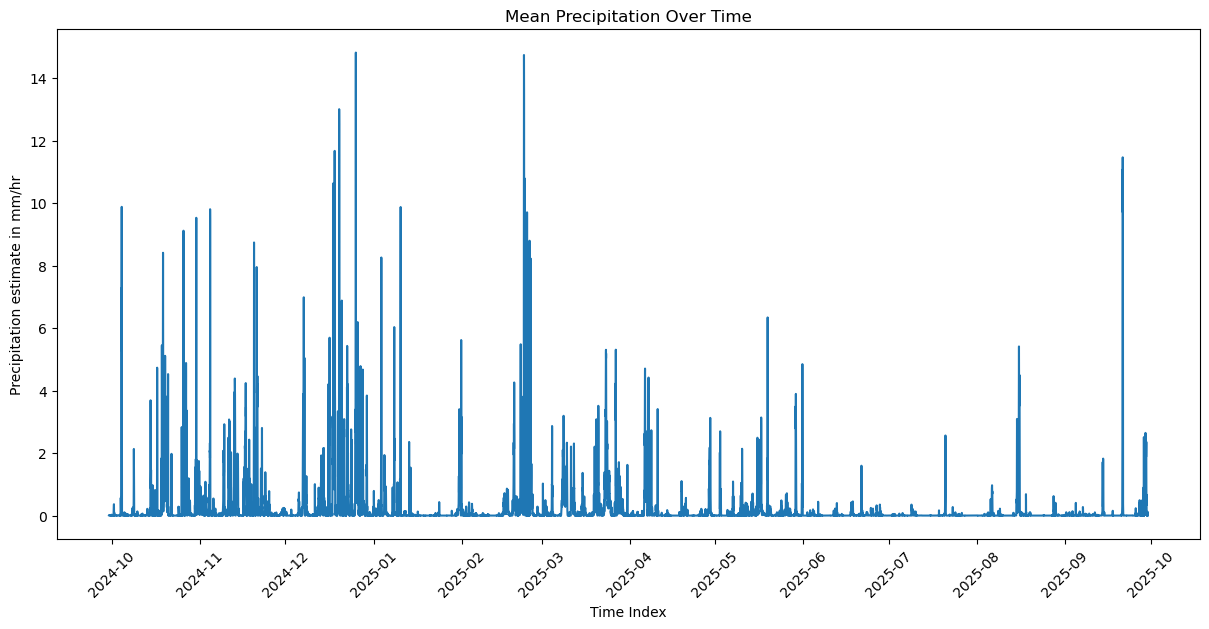

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(subset_times, precip_mean)

# Set major ticks to months
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()

plt.title("Mean Precipitation Over Time")
plt.xlabel("Time Index")
plt.ylabel("Precipitation estimate in mm/hr")  # Replace with correct units
plt.show()


In [35]:
minx  = -101.6
miny  =  35.7
maxx  = -101.56
maxy  =  35.8

# minx  = -93.367859	## Causes error with x values I have
# miny  =  29.896942
# #maxx  = -93.340860 # Doesn't work 
# #maxx  = -93.2 # works
# #maxx  = -93.3 # works
# maxx = -93.335 # Doesn't work
# #maxx  = -93.35 # Doesn't work
# maxy  =  29.919701

In [36]:
%%time
xds = extract_subset(
    store,
    "precipitation",
    time=("2019-03-13 12:00:00", "2019-03-14 12:00:00"),
    lat=(miny, maxy),
    lon=(minx, maxx),
    as_xarray=True
)

CPU times: user 0 ns, sys: 3.96 ms, total: 3.96 ms
Wall time: 3.22 ms


In [37]:
longitude = np.mean(xds['lon'].values)  # Taking mean so that multiple close values of longitude work the same as a point
desired_lst_start_hour = 1.5  # 1:30 AM
lst_to_utc_offset_hours = longitude / 15.0  
lst_to_utc_offset_hours

utc_anchor_hour = (desired_lst_start_hour - lst_to_utc_offset_hours) % 12
offset_timedelta = pd.Timedelta(hours=utc_anchor_hour)

# Resample the data natively in UTC
resampled_da = xds.resample(time="12h", offset=offset_timedelta).sum()

if (resampled_da["lon"].values.size >= 1):
    spatial_dims = ["lon", "lat"]
    agg = getattr(resampled_da, "max")(dim=spatial_dims) 

df = agg.to_dataframe().reset_index()
df

ValueError: cannot convert float NaN to integer